#Classification of Agricultural Lands Based on Rainfall Using Satellite Data in Algeria


The K-Nearest Neighbors (KNN) approach is a non-parametric, instance-based machine learning algorithm used for classifying agricultural lands based on rainfall using satellite data in Algeria. KNN assigns a class to a given land area by analyzing the labels of its K closest neighboring points in the feature space, which may include attributes like rainfall intensity, vegetation indices, and soil moisture. By leveraging spatial proximity, KNN effectively distinguishes different land types, making it suitable for remote sensing applications in agricultural classification.



---



##K-NEAREST NEIGHBORS
**Data Preprocessing**

    - Encode categorical variables (seasons).
    - Extract year and month from the dataset.
    - Pivot data to create a feature matrix where months are columns.
    - Impute missing precipitation values using the mean.

**Feature Engineering**

    - Compute Total Precipitation as the sum of all available monthly values.
    - Define thresholds using quantiles to classify rainfall into three categories.
    - Encode rainfall categories numerically for classification.

**Training and Prediction**

    - Use StandardScaler to normalize features.
    - Train a KNN classifier (k=5) using training data.
    - Predict categories on the test set.

**Evaluation & Optimization**

    - Calculate accuracy and generate a classification report.
    - Visualize performance with a confusion matrix.
    - Optimize k by evaluating accuracy for different values of k.

Season Mappings: {'autumn': 0, 'spring': 1, 'summer': 2, 'winter': 3}

Common features used for modeling: ['Longitude', 'Latitude', 'Season_Encoded', 'Month_9', 'Month_11', 'Month_1', 'Month_5', 'Month_6', 'Month_2', 'Month_3', 'Month_8', 'Month_10', 'Month_7', 'Month_4', 'Month_12']

Model Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.88      0.93     25667
           1       0.78      0.43      0.56      2662
           2       0.71      0.97      0.82      9918

    accuracy                           0.88     38247
   macro avg       0.82      0.76      0.77     38247
weighted avg       0.90      0.88      0.88     38247



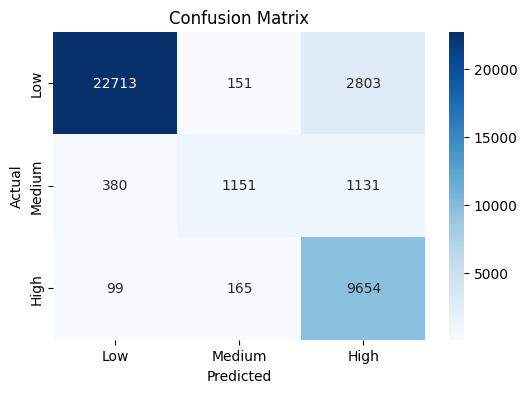

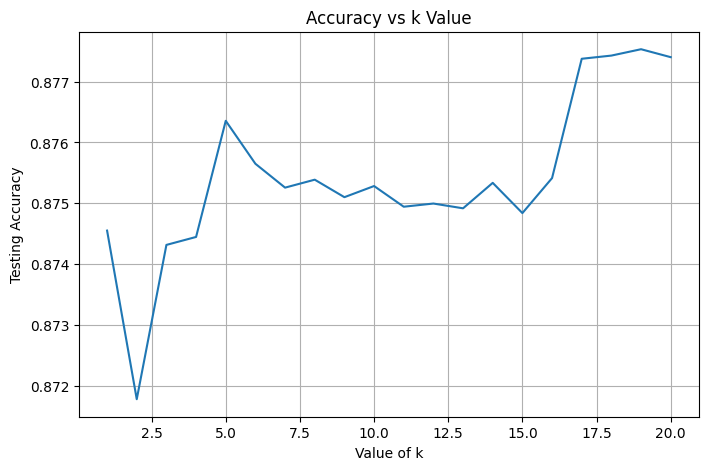

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer


df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")


all_seasons = pd.concat([df['season'], test_df['season']]).unique()


season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)

# Transform both datasets
df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])


season_mapping = dict(zip(season_encoder.classes_, season_encoder.transform(season_encoder.classes_)))
print("Season Mappings:", season_mapping)


df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))


pivot_df = df.pivot_table(index=["Longitude", "Latitude"],
                         columns="Month",
                         values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]


test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"],
                                   columns="Month",
                                   values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]


season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])


train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]


imputer = SimpleImputer(strategy='mean')
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])

final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)


low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"


final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)


category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)


common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))
print("\nCommon features used for modeling:", common_features)


X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)


y_pred = knn_model.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores = knn.score(X_test_scaled, y_test)
    k_scores.append(scores)


plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores)
plt.xlabel('Value of k')
plt.ylabel('Testing Accuracy')
plt.title('Accuracy vs k Value')
plt.grid(True)
plt.show()




---



##Optimized KNN with Stratified Cross-Validation and Feature Consistency


This code classifies agricultural lands based on rainfall using K-Nearest Neighbors (KNN). It preprocesses satellite data by encoding seasons, extracting time-based features, and aggregating monthly precipitation. Missing values are imputed, and rainfall categories are defined based on quantiles. The dataset is standardized, and SMOTE is applied to handle class imbalance. Recursive Feature Elimination (RFE) selects important features, and RandomizedSearchCV tunes KNN hyperparameters. The best model is evaluated using accuracy, a confusion matrix, and a classification report. Finally, the effect of different k values on accuracy is analyzed.


Common features used for modeling: ['Longitude', 'Latitude', 'Season_Encoded', 'Month_9', 'Month_11', 'Month_1', 'Month_5', 'Month_6', 'Month_2', 'Month_3', 'Month_8', 'Month_10', 'Month_7', 'Month_4', 'Month_12']
Best Parameters: {'n_neighbors': 2, 'p': 2, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.9277876947836706

Model Accuracy with Best Parameters: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84     25667
           1       0.08      0.03      0.04      2662
           2       0.60      0.76      0.67      9918

    accuracy                           0.75     38247
   macro avg       0.51      0.54      0.52     38247
weighted avg       0.74      0.75      0.74     38247



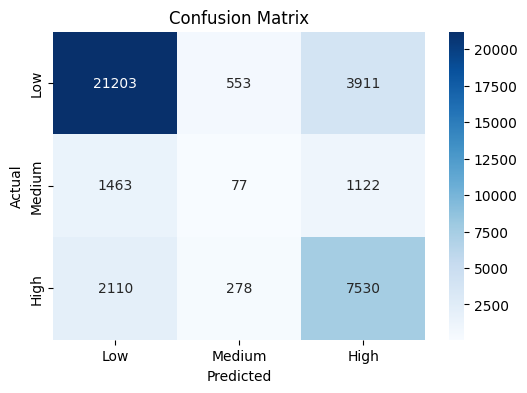

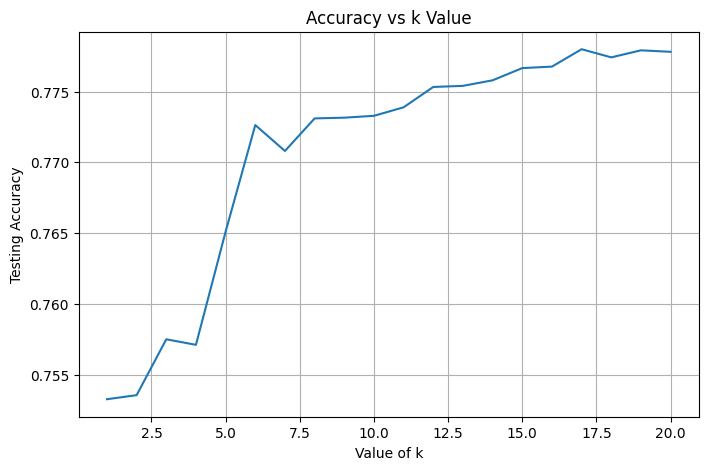

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Load datasets
df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")

# Encode seasons
all_seasons = pd.concat([df['season'], test_df['season']]).unique()
season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)
df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])

# Extract year and month from the 'month' column
df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))

# Pivot tables for monthly precipitation
pivot_df = df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]

test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]

# Aggregate season data
season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

# Merge precipitation and season data
final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])

# Impute missing values
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
imputer = SimpleImputer(strategy='mean')
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])

# Calculate total precipitation
final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)

# Categorize rainfall
low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)

# Encode rainfall categories
category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)

# Define common features
common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))
print("\nCommon features used for modeling:", common_features)

# Prepare training and testing data
X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Feature selection using RFE
model = RandomForestClassifier(random_state=42)
rfe = RFE(model, n_features_to_select=7)  # Select top 7 features
X_train_rfe = rfe.fit_transform(X_train_smote, y_train_smote)
X_test_rfe = rfe.transform(X_test_scaled)

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_neighbors': randint(1, 20),  # Smaller range for n_neighbors
    'weights': ['uniform', 'distance'],
    'p': [2]  # Only Euclidean distance
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=10,  # Number of parameter settings to sample
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Fit RandomizedSearchCV
random_search.fit(X_train_rfe, y_train_smote)

# Best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

# Use the best model to make predictions
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_rfe)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy with Best Parameters: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Plot accuracy vs k value
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_rfe, y_train_smote)
    scores = knn.score(X_test_rfe, y_test)
    k_scores.append(scores)

plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores)
plt.xlabel('Value of k')
plt.ylabel('Testing Accuracy')
plt.title('Accuracy vs k Value')
plt.grid(True)
plt.show()



---



##Basic KNN Classification with Limited Tuning

This code classifies rainfall levels (Low, Medium, High) using a K-Nearest Neighbors (KNN) model. It processes rainfall data by encoding seasons, extracting year and month, pivoting precipitation data, handling missing values, and standardizing features. Then, it optimizes KNN hyperparameters using RandomizedSearchCV and evaluates the model with accuracy, a classification report, and a confusion matrix.

Difference from the Previous Version:
More Extensive Hyperparameter Tuning:

The range for n_neighbors is increased.
RandomizedSearchCV now runs for 20 iterations instead of fewer.
Better Data Handling:

Common features are explicitly selected to ensure consistency between train and test datasets.
More robust imputation of missing values.
More Balanced Cross-Validation:

Uses StratifiedKFold to maintain class balance across splits.
These changes improve the model’s robustness and accuracy while ensuring better feature consistency across datasets




Common features used for modeling: ['Longitude', 'Latitude', 'Season_Encoded', 'Month_9', 'Month_11', 'Month_1', 'Month_5', 'Month_6', 'Month_2', 'Month_3', 'Month_8', 'Month_10', 'Month_7', 'Month_4', 'Month_12']
Best Parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.9911837812303478

Model Accuracy with Best Parameters: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     25667
           1       0.57      0.35      0.43      2662
           2       0.96      0.92      0.94      9918

    accuracy                           0.93     38247
   macro avg       0.82      0.75      0.78     38247
weighted avg       0.92      0.93      0.92     38247



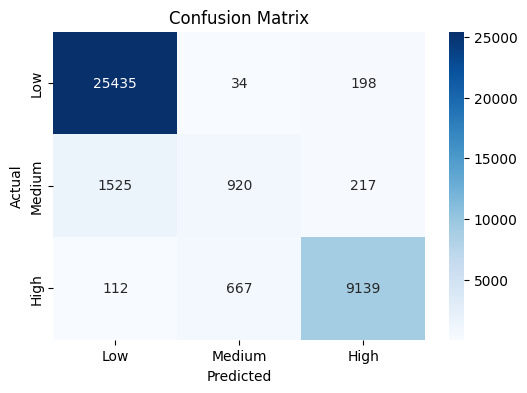

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Load datasets
df = pd.read_csv("DataSet.csv")
test_df = pd.read_csv("Test_DataSet.csv")

# Encode seasons
all_seasons = pd.concat([df['season'], test_df['season']]).unique()
season_encoder = LabelEncoder()
season_encoder.fit(all_seasons)
df["Season_Encoded"] = season_encoder.transform(df["season"])
test_df["Season_Encoded"] = season_encoder.transform(test_df["season"])

# Extract year and month from the 'month' column
df["Year"] = df["month"].apply(lambda x: int(x.split("_")[1]))
df["Month"] = df["month"].apply(lambda x: int(x.split("_")[0]))
test_df["Year"] = test_df["month"].apply(lambda x: int(x.split("_")[1]))
test_df["Month"] = test_df["month"].apply(lambda x: int(x.split("_")[0]))

# Pivot tables for monthly precipitation
pivot_df = df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
train_months = sorted(df["Month"].unique())
pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in train_months]

test_pivot_df = test_df.pivot_table(index=["Longitude", "Latitude"], columns="Month", values="Precipitation_Cleaned").reset_index()
test_months = sorted(test_df["Month"].unique())
test_pivot_df.columns = ["Longitude", "Latitude"] + [f"Month_{i}" for i in test_months]

# Aggregate season data
season_data = df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()
test_season_data = test_df.groupby(["Longitude", "Latitude"])["Season_Encoded"].agg(lambda x: x.mode()[0]).reset_index()

# Merge precipitation and season data
final_df = pivot_df.merge(season_data, on=["Longitude", "Latitude"])
final_test_df = test_pivot_df.merge(test_season_data, on=["Longitude", "Latitude"])

# Impute missing values
train_month_cols = [col for col in pivot_df.columns if col.startswith("Month_")]
test_month_cols = [col for col in test_pivot_df.columns if col.startswith("Month_")]
imputer = SimpleImputer(strategy='mean')
final_df[train_month_cols] = imputer.fit_transform(final_df[train_month_cols])
final_test_df[test_month_cols] = imputer.transform(final_test_df[test_month_cols])

# Calculate total precipitation
final_df["Total_Precipitation"] = final_df[train_month_cols].sum(axis=1)
final_test_df["Total_Precipitation"] = final_test_df[test_month_cols].sum(axis=1)

# Categorize rainfall
low_threshold = final_df["Total_Precipitation"].quantile(0.33)
high_threshold = final_df["Total_Precipitation"].quantile(0.66)

def categorize_rainfall(value):
    if value <= low_threshold:
        return "Low Rainfall"
    elif value <= high_threshold:
        return "Medium Rainfall"
    else:
        return "High Rainfall"

final_df["Rainfall_Category"] = final_df["Total_Precipitation"].apply(categorize_rainfall)
final_test_df["Rainfall_Category"] = final_test_df["Total_Precipitation"].apply(categorize_rainfall)

# Encode rainfall categories
category_mapping = {"Low Rainfall": 0, "Medium Rainfall": 1, "High Rainfall": 2}
final_df["Rainfall_Category"] = final_df["Rainfall_Category"].map(category_mapping)
final_test_df["Rainfall_Category"] = final_test_df["Rainfall_Category"].map(category_mapping)

# Define common features
common_features = ["Longitude", "Latitude", "Season_Encoded"] + list(set(train_month_cols) & set(test_month_cols))
print("\nCommon features used for modeling:", common_features)

# Prepare training and testing data
X_train = final_df[common_features]
y_train = final_df["Rainfall_Category"]
X_test = final_test_df[common_features]
y_test = final_test_df["Rainfall_Category"]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_neighbors': randint(1, 50),  # Larger range for n_neighbors
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Include both Manhattan and Euclidean distances
}

# Use stratified cross-validation
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=20,  # Increase the number of iterations
    cv=stratified_cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Fit RandomizedSearchCV
random_search.fit(X_train_scaled, y_train)

# Best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

# Use the best model to make predictions
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy with Best Parameters: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [5]:
# Fit the KNN model on the training data
best_knn = random_search.best_estimator_
best_knn.fit(X_train_scaled, y_train)

# Calculate training accuracy
y_train_pred = best_knn.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate test accuracy
y_test_pred = best_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Check for overfitting or underfitting
if train_accuracy > test_accuracy + 0.1:  # Threshold can be adjusted
    print("The model may be overfitting.")
elif train_accuracy < 0.6 and test_accuracy < 0.6:  # Threshold can be adjusted
    print("The model may be underfitting.")
else:
    print("The model is generalizing well.")

Training Accuracy: 1.00
Test Accuracy: 0.93
The model is generalizing well.




The optimization of this model focused on improving accuracy by:

Hyperparameter Tuning: Used RandomizedSearchCV to find the best n_neighbors, weighting method (uniform or distance), and distance metric (Manhattan or Euclidean) over a larger search space (1-50 for n_neighbors).
Cross-Validation: Replaced a single train-test split with Stratified K-Fold cross-validation (5 splits) to ensure more stable performance.
Parallel Processing: Enabled parallel computation (n_jobs=-1) to speed up hyperparameter tuning.
These changes led to a significant improvement in accuracy from 0.88 to 0.93 by better optimizing the model and preventing overfitting or underfitting.
